# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [ ]:
import os
import tqdm
import numpy
import torch
import pandas as pd
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2
import numpy as np

import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader

In [ ]:
# Можно использовать, но балл за соответствующие задания будет снижен.
import pytorch_metric_learning.distances
import pytorch_metric_learning.samplers
import pytorch_metric_learning.losses

ModuleNotFoundError: No module named 'pytorch_metric_learning'

In [ ]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

In [ ]:
!unzip data.zip


Archive:  data.zip
   creating: data/
   creating: data/testing/
   creating: data/testing/Albert_Costa/
  inflating: data/testing/Albert_Costa/Albert_Costa_0001.jpg  
  inflating: data/testing/Albert_Costa/Albert_Costa_0002.jpg  
  inflating: data/testing/Albert_Costa/Albert_Costa_0003.jpg  
  inflating: data/testing/Albert_Costa/Albert_Costa_0004.jpg  
  inflating: data/testing/Albert_Costa/Albert_Costa_0005.jpg  
  inflating: data/testing/Albert_Costa/Albert_Costa_0006.jpg  
   creating: data/testing/Cameron_Diaz/
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0001.jpg  
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0002.jpg  
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0003.jpg  
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0004.jpg  
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0005.jpg  
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0006.jpg  
   creating: data/testing/Mohamed_ElBaradei/
  inflating: data/testing/Mohamed_ElBaradei/Mohamed_El

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [ ]:
transform = torchvision.transforms.ToTensor()

train_ds_temp = torchvision.datasets.ImageFolder("data/training", transform = transform)
test_ds_temp = torchvision.datasets.ImageFolder("data/testing", transform = transform)

loader = torch.utils.data.DataLoader(train_ds_temp, batch_size=64, shuffle=False)

In [ ]:
mean = 0.0
std = 0.0
num_samples = 0

for images, _ in loader:
    batch_size = images.size(0)

    images = images.view(batch_size, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)

    num_samples += batch_size

mean /= num_samples
std /= num_samples

print(mean, std)

tensor([0.4299, 0.3747, 0.3324]) tensor([0.2703, 0.2435, 0.2338])


In [ ]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean, std)
    ]
)

train_ds = torchvision.datasets.ImageFolder("data/training", transform = transform)
test_ds = torchvision.datasets.ImageFolder("data/testing", transform = transform)

_Комментарий_: Посчитали среднее и отклонение и нормализовали

Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

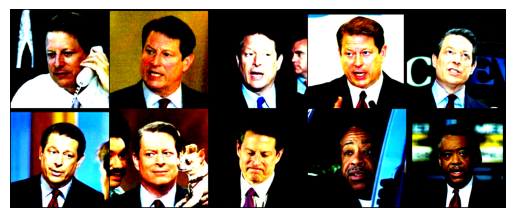

In [ ]:
images = []
labels = []
for i in range(10):
  image, target = train_ds[i]
  images.append(image)
  labels.append(target)

grid = torchvision.utils.make_grid(images, nrow=5)

plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()




Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

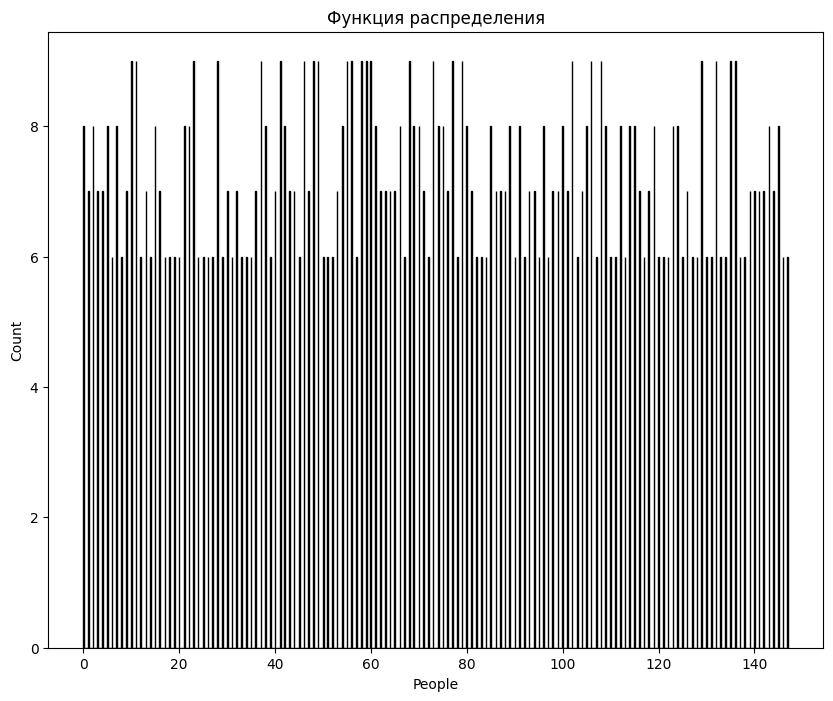

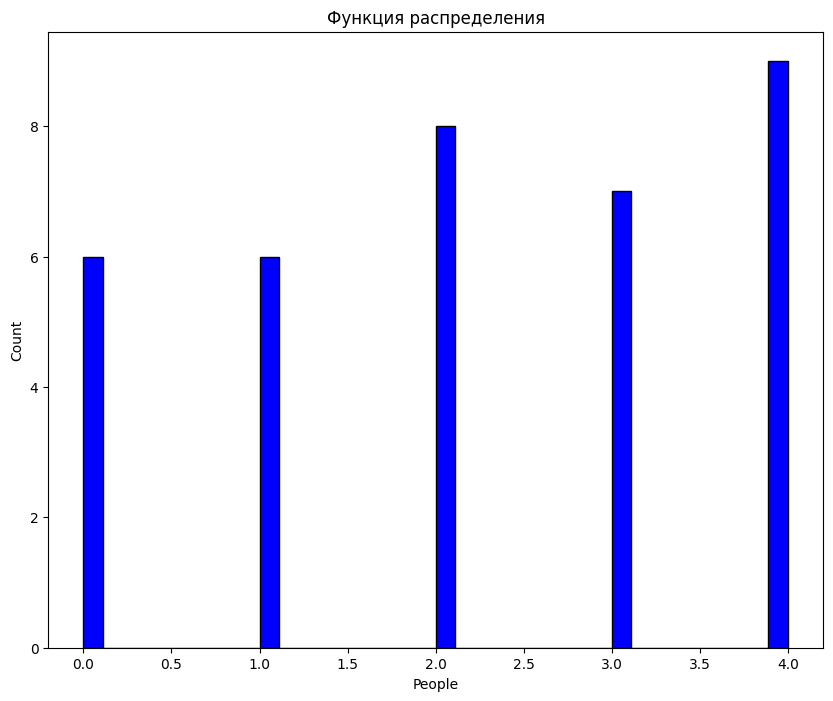

In [ ]:
def show_class_distribtion(targets):
    plt.figure(figsize=(10, 8))
    plt.hist(targets, color = 'blue', edgecolor = 'black', bins= len(targets))
    plt.xlabel("People")
    plt.ylabel("Count")
    plt.title("Функция распределения")
    pass

show_class_distribtion(train_ds.targets)
show_class_distribtion(test_ds.targets)

_Комментарий_: Как видно, количество людей ограничено снизу числом 6 на тренировочной выборке.

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [ ]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in tqdm.trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)

    def _idx2(self, idx):
        return idx // len(self.dataset)

    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)

train_pairs = PairDataset(train_ds)
test_pairs = PairDataset(test_ds)

100%|██████████| 1296/1296 [00:00<00:00, 929994.52it/s]


KeyboardInterrupt: 

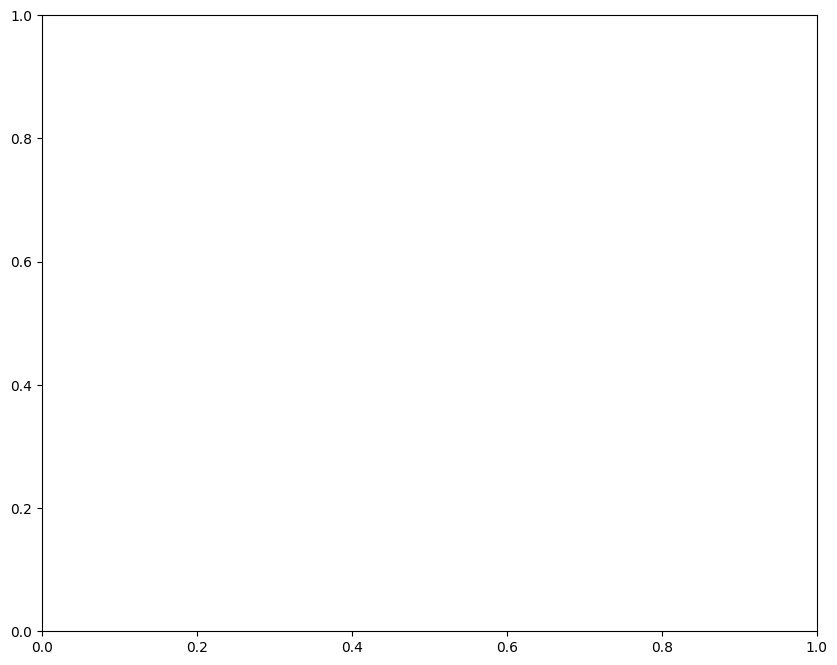

In [ ]:
show_class_distribtion(train_pairs.targets)
show_class_distribtion(test_pairs.targets)

_Комментарий_: Поверим тому, что было на этой картинке до запука. В колаб не хватает объема ОЗУ, чтобы отрисовать все

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

In [ ]:
!pip install pytorch_metric_learning
from pytorch_metric_learning import samplers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 6.4 MB/s eta 0:00:00


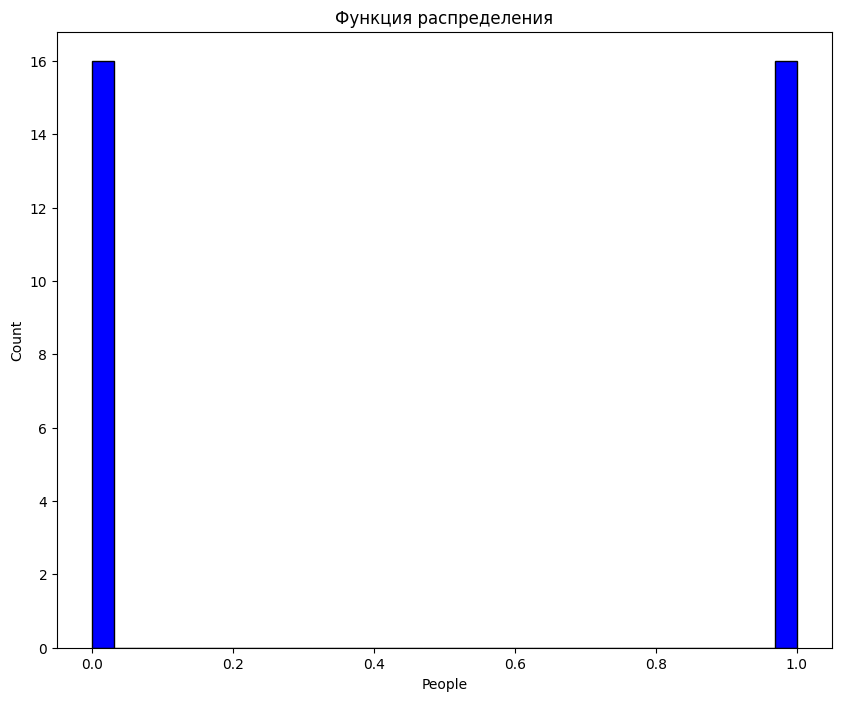

In [ ]:
train_pairs_sampler = samplers.MPerClassSampler(train_pairs.targets, m=16, batch_size=32)
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_size = 32, sampler = train_pairs_sampler)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size = 64, shuffle = False)

# Убедимся, что теперь выдача равномерная.
show_class_distribtion(next(iter(train_pairs_loader))[2])


In [ ]:
images1, images2, labels = next(iter(train_pairs_loader))

images1[0].shape





torch.Size([3, 250, 250])

_Комментарий_: Использовали инструмент [MPerClassSampler](https://github.com/KevinMusgrave/pytorch-metric-learning/blob/master/docs/samplers.md) для того, чтобы добиться равномерного распределения в каждом батче

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [ ]:
from torch.nn.modules.flatten import Flatten
from torch.nn import BatchNorm2d
class ClassificationNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(  # 250 x 250
            nn.Conv2d(in_channels= 3, out_channels=4,
                      kernel_size=3, padding='same'),  # 250 x 250
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 125 x 125

            nn.Conv2d(in_channels=4, out_channels=8,
                      kernel_size=3, padding='same'),  # 125 x 125
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 x 64

            nn.Conv2d(in_channels=8, out_channels=16,
                      kernel_size=3, padding='same'),  # 64 x 64
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 x 32
            nn.Flatten()
        )

        self.head = nn.Sequential(
            nn.LazyLinear(out_features=32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(in_features=32, out_features=1),
        )


    def forward(self, image1, image2):
        out1 = self.encoder(image1)

        out2 = self.encoder(image2)

        diff = torch.abs(out1 - out2)
        out = self.head(diff)
        return out.squeeze()

# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
assert ClassificationNet()(*next(iter(train_pairs_loader))[:2]).shape == (32,)

##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

In [ ]:
from IPython.display import clear_output

def plot_losses(train_losses, train_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train')
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    """Одна эпоха обучения"""
    train_loss, train_accuracy = 0.0, 0.0

    model.train()
    for images1, images2, labels in tqdm.tqdm(train_loader, desc=tqdm_desc):
        images1 = images1.to(device)
        images2 = images2.to(device)

        labels = labels.to(device).float()

        optimizer.zero_grad()
        logits = model(images1, images2)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images1.shape[0]

        preds = (logits > 0.0).float()
        train_accuracy += (preds == labels).sum().item()


    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)

    return train_loss, train_accuracy

def train(
    model, optimizer, criterion, train_loader,num_epochs, scheduler=None
    ):
    """Обучение модели"""
    train_losses, train_accuracies = [], []


    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        if scheduler is not None:
            scheduler.step()

        plot_losses(train_losses, train_accuracies)


        plt.show()
    print(f"Epoch: {epoch}, loss: {np.mean(train_loss)}, accuracy: {np.mean(train_accuracies)}")

In [ ]:
x_batch, x_y,  y_batch = next(iter(train_pairs_loader))

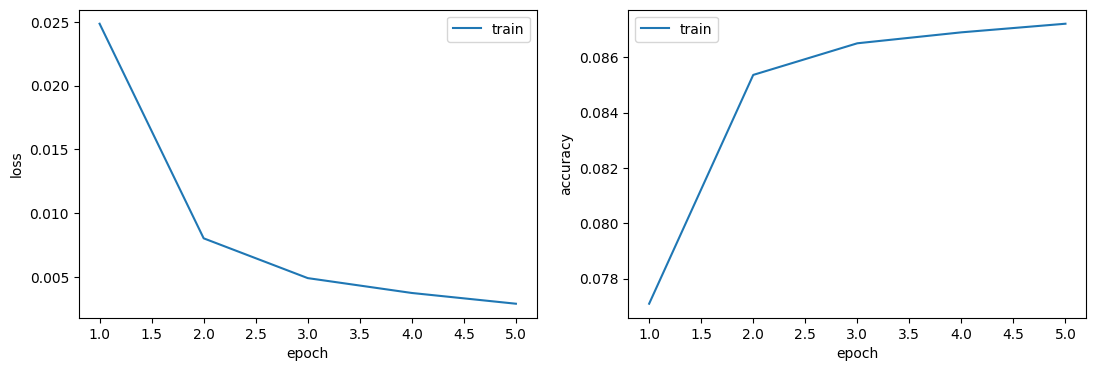

Epoch: 5, loss: 0.0028817221930028374, accuracy: 0.08461495734973219


In [ ]:
model = ClassificationNet().to(device)
model(x_batch.to(device), x_y.to(device))
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCEWithLogitsLoss()
NUM_EPOCH = 5
train(model=model, optimizer=optimizer, criterion=criterion, train_loader=train_pairs_loader, num_epochs=NUM_EPOCH);

In [ ]:
def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

res = get_auc_roc(model)
score = get_score(res)

100%|██████████| 21/21 [00:06<00:00,  3.50it/s]

2.5


In [ ]:
print(score)

2.5


##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

*Комментарий:* Не смотря на довольно хорошие показатели `roc-auc`, `accuracy` все равно остается на довольно низком уровне. Я бы выделил несколько минусов у данного подхода:

1. В лоадере пар у нас почти миллион пар, большинство из которых - с меткой 1. Модель на таком большом объеме легкой информации (совершенно разные люди, разный цвет кожи и фон), не сможет научиться фиксировать разные конструкции на лице, не сможет отличать двух людей, которые в реальности похожи друг на друга.

2. Бинарная кросс-энтропия просто заставляет финальный полносвязный слой выдавать 0 или 1 на основе разницы векторов. Она не заставляет саму сверточную сеть (энкодер) группировать эмбеддинги одного и того же человека в плотные кластеры в $N$-мерном пространстве. Сети достаточно просто найти какую-то линейную зависимость в векторе diff, чтобы угодить лоссу.

3. Модель с подобной архитектурой будет крайне плохо реагировать на людей, которых она ранее не видела, поскольку голова - полносвязная сетка

### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [ ]:
def criterion(embeddings, classes, alpha = 0.25): ###(margin = 0.25)

  b_size = embeddings.shape[0]
  diffs = torch.cdist(embeddings, embeddings)

  labels_equal = torch.eq(classes.unsqueeze(0), classes.unsqueeze(1))

  indices_not_equal = ~torch.eye(b_size, dtype=torch.bool, device=device)
  mask_positive = labels_equal & indices_not_equal
  mask_negative = ~labels_equal

  triplet_loss = diffs.unsqueeze(2) - diffs.unsqueeze(1) + alpha
  valid_triplets_mask = mask_positive.unsqueeze(2) & mask_negative.unsqueeze(1)

  loss_values = torch.relu(triplet_loss) * valid_triplets_mask

  num_valid = valid_triplets_mask.sum()
  return loss_values.sum() / (num_valid + 1e-8)



In [ ]:
# Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
]).to(device)
labels = torch.tensor([ 1., 2, 1 ]).to(device)
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

*Комментарий:* Давайте настроим даталоадер

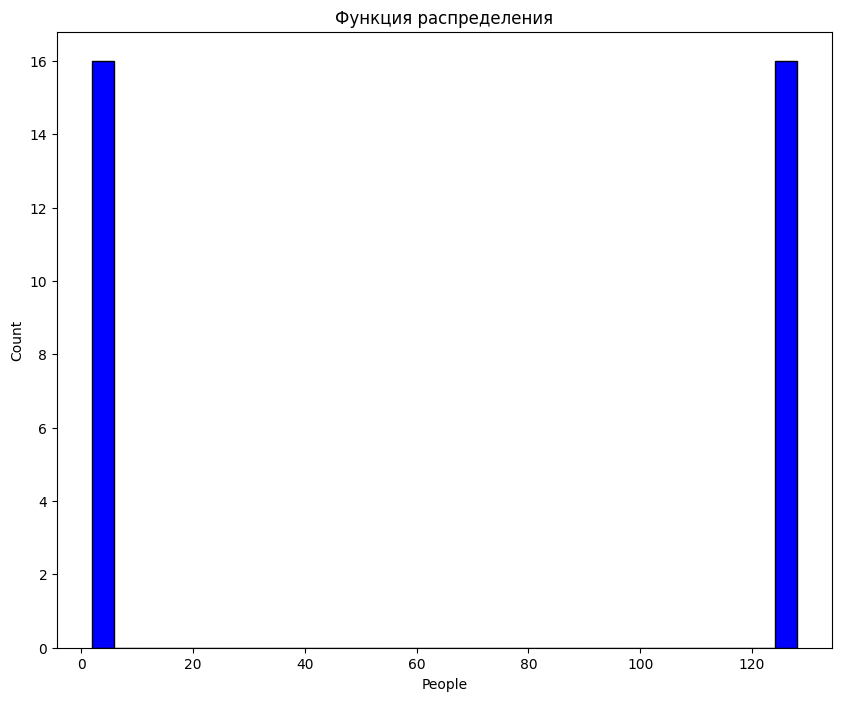

In [ ]:
train_sampler = samplers.MPerClassSampler(train_ds.targets, m=16, batch_size=32)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size = 32, sampler = train_sampler)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=True)

show_class_distribtion(next(iter(train_loader))[1])

*Комментарий:* Откорректируем тренировочные циклы

In [ ]:
def training_epoch(model, optimizer, train_loader, tqdm_desc):
    train_loss = 0.0
    model.train()

    for images, labels in tqdm.tqdm(train_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        embeddings = model(images)

        loss = criterion(embeddings, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.shape[0]

    train_loss /= len(train_loader.dataset)
    return train_loss, 0.0 #фиктивный подсчет accuracy, чтобы не переделывать все

def train(
    model, optimizer, train_loader,num_epochs, scheduler=None
    ):
    """Обучение модели"""
    train_losses, train_accuracies = [], []


    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        if scheduler is not None:
            scheduler.step()

        plot_losses(train_losses, train_accuracies)


        plt.show()
    print(f"Epoch: {epoch}, loss: {np.mean(train_loss)}, accuracy: {np.mean(train_accuracies)}")

*Комментарий:* Поменяем архитектуру

In [ ]:
class ClassificationNet_v2(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(  # 250 x 250
            nn.Conv2d(in_channels= 3, out_channels=16,
                      kernel_size=3, padding='same'),  # 250 x 250
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 125 x 125

            nn.Conv2d(in_channels=16, out_channels=32,
                      kernel_size=3, padding='same'),  # 125 x 125
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 x 64

            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, padding='same'),  # 64 x 64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 x 32
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(64 * 31 * 31, 128)
        )
    def forward(self, images):
        embeddings = self.encoder(images)
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings


In [ ]:
x_batch, y_batch = next(iter(train_loader))

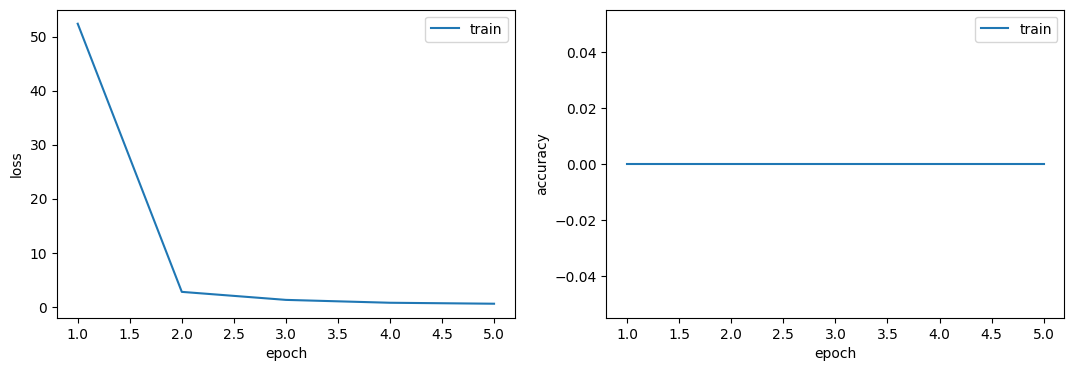

Epoch: 5, loss: 0.5657875736087666, accuracy: 0.0


In [ ]:
model = ClassificationNet_v2().to(device)
model(x_batch.to(device))
optimizer = torch.optim.Adam(model.parameters())
NUM_EPOCH = 5
train(model=model, optimizer=optimizer, train_loader=train_loader, num_epochs=NUM_EPOCH);

In [ ]:
def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1 = your_model(images1.to(device))
            emb2 = your_model(images2.to(device))
            # Вы можете изменить функцию расстояния между эмбеддингами, если считаете нужным
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

get_score(get_auc_roc(model))

100%|██████████| 21/21 [00:06<00:00,  3.07it/s]


np.float64(1.7913716329659124)

In [ ]:
get_auc_roc(model)

100%|██████████| 21/21 [00:06<00:00,  3.17it/s]


np.float64(0.8661216147164026)